First part plots scatter plots for pairs of features in the original higher-dimensional data, and the second part applies t-SNE and plots the results in a 2D space.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.manifold import TSNE

In [ ]:
#loading the iris dataset
iris = datasets.load_iris()
x= iris.data
y = iris.target

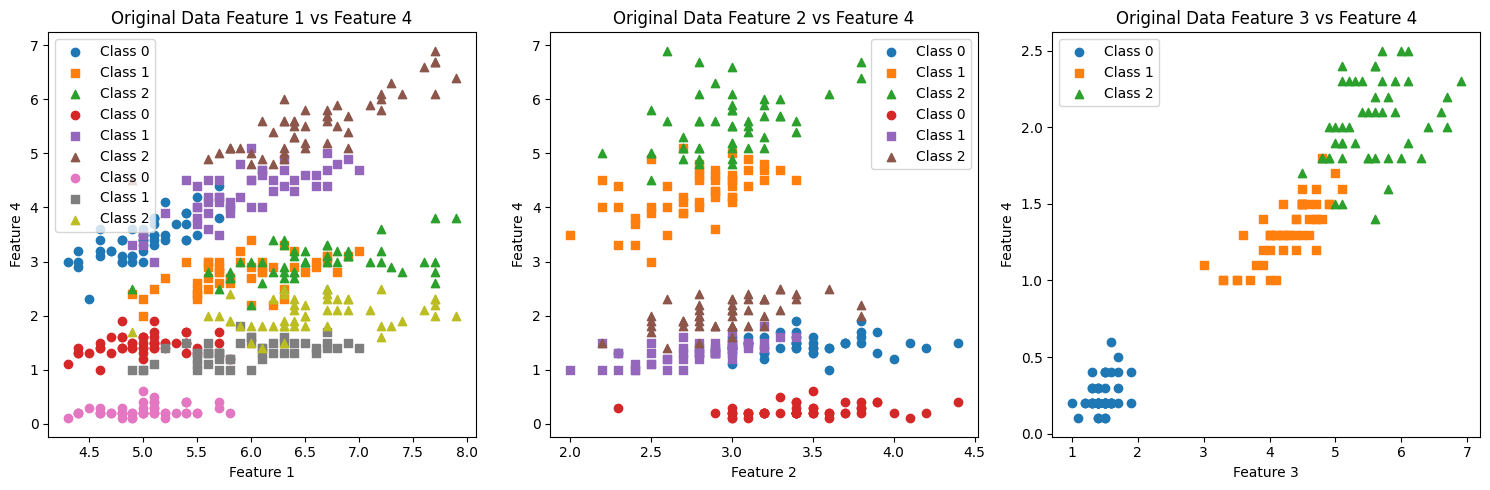

In [ ]:
#scatter plot for pairs od feature
plt.figure(figsize=(15,5))
for i in range(3):
  plt.subplot(1,3,i+1)
  for j in range(i+1,4):
    plt.scatter(x[y==0,i],x[y==0,j],label="Class 0",marker='o')
    plt.scatter(x[y==1,i],x[y==1,j],label="Class 1",marker='s')
    plt.scatter(x[y==2,i],x[y==2,j],label="Class 2",marker='^')
    plt.title(f'Original Data Feature {i+1} vs Feature {j+1}')
    plt.xlabel(f'Feature {i+1}')
    plt.ylabel(f'Feature {j+1}')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
tsne = TSNE(n_components=2,random_state=42)
X_tsne = tsne.fit_transform(x)

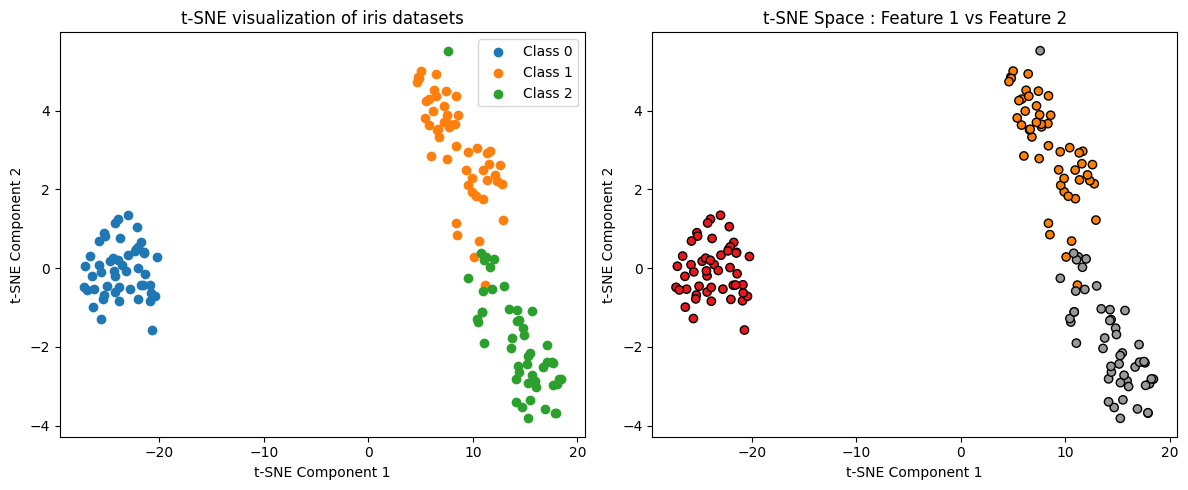

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i in range(3):
  plt.scatter(X_tsne[y==i,0],X_tsne[y==i,1],label=f'Class {i}')
plt.title("t-SNE visualization of iris datasets")
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()

plt.subplot(1,2,2)
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=y,cmap=plt.cm.Set1,edgecolor='k')
plt.title("t-SNE Space : Feature 1 vs Feature 2")
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.tight_layout()
plt.show()

Problem Statement: We have handwritten digit images. Each image is converted into 64 numerical pixel features. We want to visualoze whether different digits from natural groups in a lower-dimensional space.


We will:

*   Load the digits dataset
*   Inspect image samples
*  Standarize the data
*  Apply t_SNE
*  Visualize the 2D Embeddding
*  Compute useful metrics such as : silhouette Score, trustworthinsess, kNN Classification accuracy in t_SNE space



In [ ]:
# Load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE,trustworthiness
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Load dataset
digits = load_digits()
x = digits.data
y = digits.target
images = digits.images

print("Dataset Shape:",x.shape)
print("Target Shape:",y.shape)
print("Classes:",np.unique(y))

Dataset Shape: (1797, 64)
Target Shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


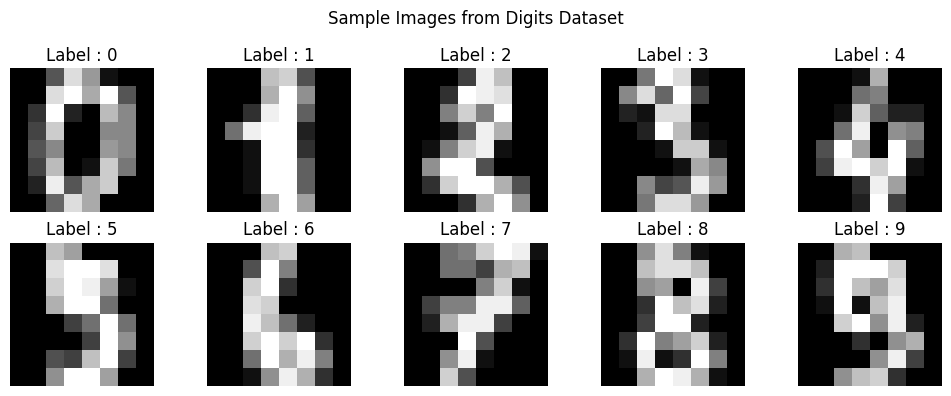

In [ ]:
# Visualize sample digit images

plt.figure(figsize=(10,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(images[i],cmap='gray')
  plt.title(f"Label : {y[i]}")
  plt.axis('off')

plt.suptitle("Sample Images from Digits Dataset")
plt.tight_layout()
plt.show()

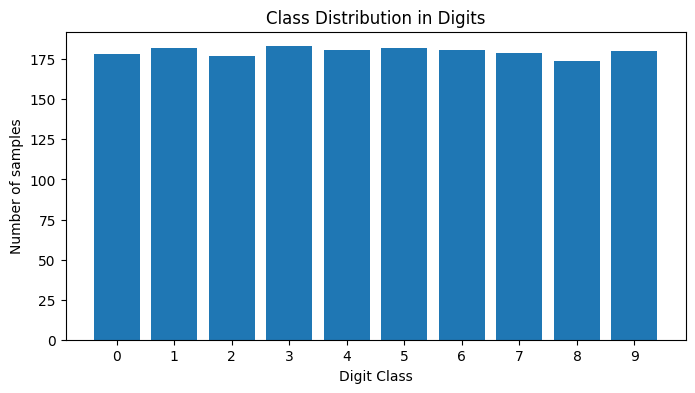

In [ ]:
# Visualize class distribution
unique_classes, counts = np.unique(y,return_counts=True)

plt.figure(figsize=(8,4))
plt.bar(unique_classes,counts)
plt.title("Class Distribution in Digits")
plt.xlabel("Digit Class")
plt.ylabel("Number of samples")
plt.xticks(unique_classes)
plt.show()

In [ ]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [ ]:
tsne = TSNE(n_components=2,perplexity=30,learning_rate='auto',init='pca',random_state=42)

x_tsne = tsne.fit_transform(X_scaled)
print("t-SNE output shape:",x_tsne.shape)

t-SNE output shape: (150, 2)


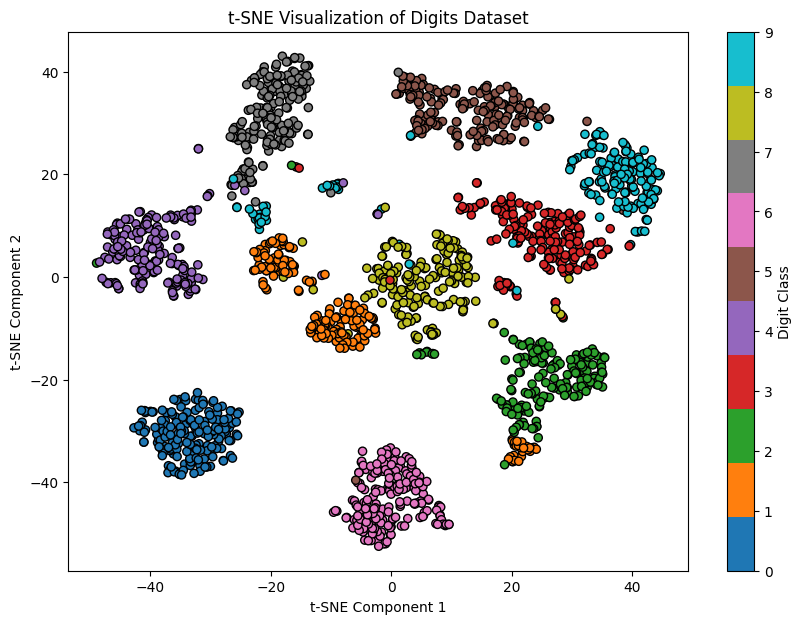

In [ ]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(x_tsne[:,0],x_tsne[:,1],c=y,cmap='tab10',s=35,edgecolor='k')
plt.colorbar(scatter,label="Digit Class")
plt.title("t-SNE Visualization of Digits Dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

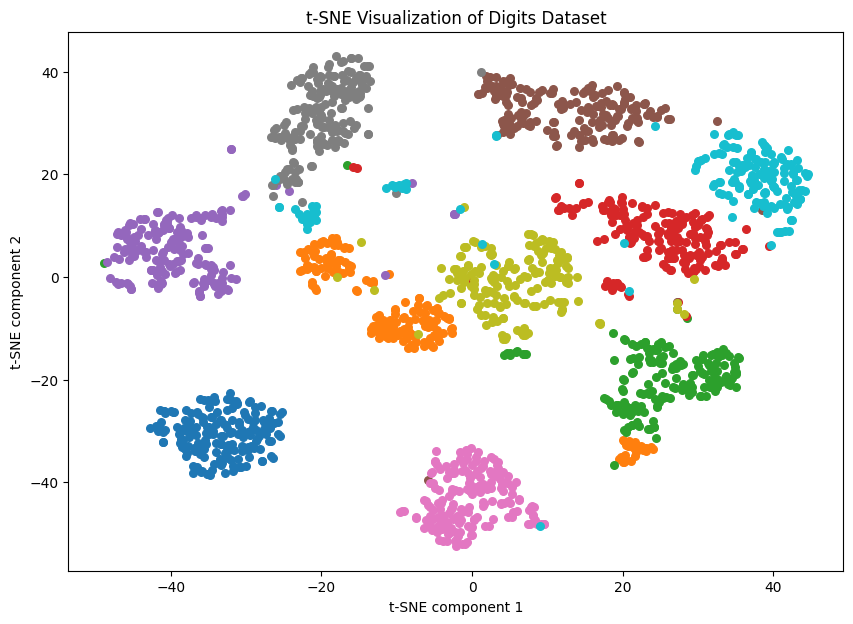

In [ ]:
plt.figure(figsize=(10,7))
for digit in np.unique(y):
    plt.scatter(
        x_tsne[y==digit,0],
        x_tsne[y==digit,1],
        label=f"digit {digit}",
        s=30
        )
plt.title("t-SNE Visualization of Digits Dataset")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.show()

In [ ]:
tw_score = trustworthiness(X_scaled,x_tsne)
print(f'Trustworthiness (n-neighbours=10):{tw_score:.4f}')

Trustworthiness (n-neighbours=10):0.9928


In [ ]:
sil_score = silhouette_score(x_tsne,y)
print(f'Silhouette score in t-sne space:{sil_score:.4f}')

Silhouette score in t-sne space:0.4848


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    x_tsne,y,test_size=0.3,random_state=42,stratify=y
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

accuracy = knn.score(X_test,y_test)
print(f"K-NN accuracy in t-SNE space : {accuracy:.4f}")

K-NN accuracy in t-SNE space : 0.9704


In [ ]:
y_pred = knn.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      1.00      0.97        55
           2       0.98      0.96      0.97        53
           3       0.98      1.00      0.99        55
           4       0.98      0.93      0.95        54
           5       0.98      0.98      0.98        55
           6       0.98      1.00      0.99        54
           7       0.95      0.98      0.96        54
           8       0.92      0.90      0.91        52
           9       0.98      0.94      0.96        54

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540

Confusion Matrix:
[[54  0  0  0  0  0  0  0  0  0]
 [ 0 55  0  0  0  0  0  0  0  0]
 [ 0  0 51  0  1  0  0  0  1  0]
 [ 0  0  0 55  0  0  0  0  0  0]
 [ 0  0  0  0 50  0  0  3  1  0]
 [ 0  0  0  0  0 54  0  0  0  1]
 